### Код для локального сервера

In [ ]:
import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import OrdinalEncoder
import torch
from torch import nn
import torch.functional as F
from torch.utils.data import DataLoader, Subset, random_split

from torchvision.transforms import InterpolationMode
from torchvision import models
from torchvision.datasets import VisionDataset
from torchvision.transforms import ToTensor, Resize, Normalize, Compose, RandomResizedCrop, ColorJitter, RandomHorizontalFlip, RandomPerspective, RandomRotation, InterpolationMode, RandomApply, GaussianBlur

import random
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

from PIL import Image

from tqdm import tqdm
import re

import os
import requests

import warnings
warnings.filterwarnings("ignore")

root_dir = "data"
img_dir = "images"
csv_path = "data_final.csv"

In [ ]:
def get_idx_row_from_image(img_name, data):
    (id, img_num) = img_name.split(".")[0].split("_")
    id = int(id)
    img_num = int(img_num)
    series = data[(data["ID"] == id) & (data["img_num"] == img_num)]
    idx = series.index[0]
    row = series.iloc[0]

    return (idx, row)

In [ ]:
class Facade(VisionDataset):
    def __init__(self, root_dir, img_dir, csv_path, attr, transform=None):
        self.attr = attr
        self.root_dir = root_dir
        self.img_dir = img_dir
        self.csv_path = csv_path

        super().__init__(self.root_dir, transform=transform)

        self.transform = transform

        self.image_paths = []
        self.labels = []
        self.orig_indices = []

        self._build_dataset()

    def _build_dataset(self):
        data = pd.read_csv(os.path.join(self.root_dir, self.csv_path))
        for img_name in os.listdir(os.path.join(self.root_dir, self.img_dir)):
            #idx = int(img_name.split('.')[0]) // old

            idx, row = get_idx_row_from_image(img_name, data)

            if row.attr != self.attr:
                continue

            self.labels.append(row.attr_val)
            self.orig_indices.append(idx)

            img_path = os.path.join(self.root_dir, self.img_dir, img_name)
            self.image_paths.append(img_path)

        print(f"Dataset loaded: {len(self.image_paths)} images")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
default_transform = Compose(
    [Resize((384, 384)), ToTensor(), Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]
)

ds = Facade(transform=default_transform, root_dir=root_dir, img_dir=img_dir, csv_path=csv_path, attr="Нарушения в содержание дорог, МАФов, остановочных павильонов, опор УНО, опор мосгортранс")

Dataset loaded: 3453 images


In [ ]:
train_test_split = 0.9
train_val_split = 1
train_size = int(train_test_split * len(ds))
test_size = len(ds) - train_size
val_size = train_size - int(train_size * train_val_split)
train_size = int(train_size * train_val_split)

generator = torch.Generator().manual_seed(42)
train_ds, val_ds, test_ds = random_split(ds, [train_size, val_size, test_size], generator=generator)

#### Аугментации

In [ ]:
train_transform = Compose([
    RandomResizedCrop(
        size=(384, 384),
        scale=(0.7, 1.0),
        ratio=(0.9, 1.1)
    ),
    RandomHorizontalFlip(p=0.5),

    ColorJitter(
        brightness=0.2,
        contrast=0.3,
        saturation=0.15,
        hue=0.05
    ),

    RandomApply([
        GaussianBlur(kernel_size=3, sigma=(0.1, 0.7))
    ], p=0.2),

    RandomApply([
        RandomRotation(
            degrees=7,
            interpolation=InterpolationMode.BILINEAR
        )
    ], p=0.3),

    RandomApply([
        RandomPerspective(
            distortion_scale=0.15,
            p=1.0
        )
    ], p=0.2),

    ToTensor(),

    Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

default_transform = Compose([
    Resize((384, 384)),
    ToTensor(),
    Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

train_ds.transform = train_transform

#### Модельки

In [ ]:
def train_model(model, train_loader, val_loader, epochs, lr, do_val, majority_weight=None):
    criterion = nn.BCEWithLogitsLoss()
    if majority_weight:
        criterion.pos_weight = torch.tensor([majority_weight], device=device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01, betas=(0.9, 0.999))

    history = {"train_loss": []}
    if do_val:
        history["val_auc"] = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        print("Training:")
        for x, y in tqdm(train_loader):
            x = x.to(device)
            y = y.to(device).float().view(-1, 1)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_loss = train_loss / len(train_loader)
        history["train_loss"].append(avg_loss)

        print(f"Epoch {epoch+1}/{epochs}:")
        print(f"  Train loss: {avg_loss:.4f}")


        if not do_val:
            continue

        model.eval()
        all_probs = []
        all_y = []

        print("Validation:")
        with torch.no_grad():
            for x, y in tqdm(val_loader):
                x, y = x.to(device), y.to(device).float()
                out = model(x)

                probs = torch.sigmoid(out).float()
                all_probs.append(probs.cpu())
                all_y.append(y.cpu())

        all_probs = torch.cat(all_probs).numpy().ravel()
        all_y = torch.cat(all_y).numpy().ravel()

        all_preds_03 = np.float32(all_probs > 0.3)
        all_preds_05 = np.float32(all_probs > 0.5)
        all_preds_07 = np.float32(all_probs > 0.7)
        val_acc_03 = accuracy_score(all_y, all_preds_03)
        val_bacc_03 = balanced_accuracy_score(all_y, all_preds_03)
        val_acc_05 = accuracy_score(all_y, all_preds_05)
        val_bacc_05 = balanced_accuracy_score(all_y, all_preds_05)
        val_acc_07 = accuracy_score(all_y, all_preds_07)
        val_bacc_07 = balanced_accuracy_score(all_y, all_preds_07)

        val_auc = roc_auc_score(all_y, all_probs)

        print(f"  Val auc: {val_auc:.4f}\n")
        print(f"  Val acc (thresh=0.3): {val_acc_03:.4f}\n")
        print(f"  Val balanced acc (thresh=0.3): {val_bacc_03:.4f}\n")
        print(f"  Val acc (thresh=0.5): {val_acc_05:.4f}\n")
        print(f"  Val balanced acc (thresh=0.5): {val_bacc_05:.4f}\n")
        print(f"  Val acc (thresh=0.7): {val_acc_07:.4f}\n")
        print(f"  Val balanced acc (thresh=0.7): {val_bacc_07:.4f}\n")
        history["val_auc"].append(val_auc)

    return history

In [ ]:
model = models.convnext_small(weights="ConvNeXt_Small_Weights.DEFAULT")

for p in model.parameters():
    p.requires_grad = False

model.classifier[2] = nn.Linear(model.classifier[2].in_features, 1, bias=True)

#### Треним

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
device

'cuda'

In [ ]:
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

hist = train_model(model, train_loader=train_loader, val_loader=val_loader, epochs=5, lr=0.001, do_val=True, majority_weight=0.43/0.57)

Training:


100%|██████████████████████████████████████████████████████████████████████████████████| 49/49 [01:00<00:00,  1.23s/it]


Epoch 1/5:
  Train loss: 0.4508
Validation:


100%|████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:06<00:00,  1.15s/it]


  Val auc: 0.7098

  Val acc (thresh=0.3): 0.7659

  Val balanced acc (thresh=0.3): 0.5000

  Val acc (thresh=0.5): 0.7688

  Val balanced acc (thresh=0.5): 0.5105

  Val acc (thresh=0.7): 0.7457

  Val balanced acc (thresh=0.7): 0.6497

Training:


...

  Val auc: 0.7425

  Val acc (thresh=0.3): 0.7746

  Val balanced acc (thresh=0.3): 0.5228

  Val acc (thresh=0.5): 0.7919

  Val balanced acc (thresh=0.5): 0.6027

  Val acc (thresh=0.7): 0.7254

  Val balanced acc (thresh=0.7): 0.6493

Training:


100%|██████████████████████████████████████████████████████████████████████████████████| 49/49 [00:51<00:00,  1.05s/it]


Epoch 5/5:
  Train loss: 0.3645
Validation:


100%|████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:05<00:00,  1.09it/s]

  Val auc: 0.7413

  Val acc (thresh=0.3): 0.7861

  Val balanced acc (thresh=0.3): 0.5646

  Val acc (thresh=0.5): 0.7890

  Val balanced acc (thresh=0.5): 0.6265

  Val acc (thresh=0.7): 0.6994

  Val balanced acc (thresh=0.7): 0.6966



#### Тюним

батч поменьше

In [ ]:
for p in model.parameters():
    p.requires_grad = True

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

fine_tuning_hist = train_model(model, train_loader=train_loader, val_loader=val_loader, epochs=7, lr=0.00001, do_val=True)

Training:


100%|████████████████████████████████████████████████████████████████████████████████| 195/195 [01:58<00:00,  1.64it/s]


Epoch 1/7:
  Train loss: 0.3850
Validation:


100%|████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:05<00:00,  1.12it/s]


  Val auc: 0.7837

  Val acc (thresh=0.3): 0.7948

  Val balanced acc (thresh=0.3): 0.5832

  Val acc (thresh=0.5): 0.8006

  Val balanced acc (thresh=0.5): 0.6212

  Val acc (thresh=0.7): 0.7717

  Val balanced acc (thresh=0.7): 0.6581

Training:


...

  Val auc: 0.8452

  Val acc (thresh=0.3): 0.8179

  Val balanced acc (thresh=0.3): 0.6625

  Val acc (thresh=0.5): 0.8121

  Val balanced acc (thresh=0.5): 0.6802

  Val acc (thresh=0.7): 0.7977

  Val balanced acc (thresh=0.7): 0.6965

Training:


100%|████████████████████████████████████████████████████████████████████████████████| 195/195 [02:11<00:00,  1.49it/s]


Epoch 7/7:
  Train loss: 0.0868
Validation:


100%|████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:06<00:00,  1.03s/it]

  Val auc: 0.8524

  Val acc (thresh=0.3): 0.8150

  Val balanced acc (thresh=0.3): 0.6435

  Val acc (thresh=0.5): 0.8150

  Val balanced acc (thresh=0.5): 0.6692

  Val acc (thresh=0.7): 0.8150

  Val balanced acc (thresh=0.7): 0.6992



#### Тестим

100%|██████████████████████████████████████████████████████████████████████████████████| 11/11 [00:06<00:00,  1.75it/s]


  Test accuracy: 0.8150
  Test balanced accuracy: 0.6692
  Test f1: 0.8865
  Test precision: 0.8361
  Test recall: 0.9434
  Test auc: 0.8524


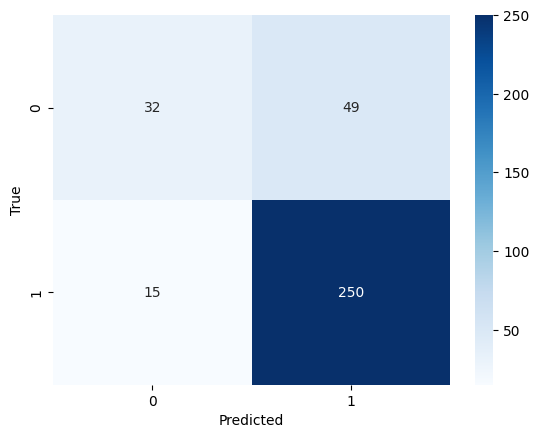

In [ ]:
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

classify_thresh=0.5

model.eval()
all_preds = []
all_probs = []
all_y = []

with torch.no_grad():
    for x, y in tqdm(test_loader):
        x, y = x.to(device), y.to(device).float()
        out = model(x)

        preds = (torch.sigmoid(out) > classify_thresh).float()
        probs = torch.sigmoid(out).float()
        all_probs.append(probs.cpu())
        all_preds.append(preds.cpu())
        all_y.append(y.cpu())


all_probs = torch.cat(all_probs).numpy().ravel()
all_preds = torch.cat(all_preds).numpy().ravel()
all_y = torch.cat(all_y).numpy().ravel()

test_acc = (all_preds == all_y).mean()
test_bacc = balanced_accuracy_score(all_y, all_preds)
test_f1 = f1_score(all_y, all_preds, zero_division=0)
test_precision = precision_score(all_y, all_preds, zero_division=0)
test_recall = recall_score(all_y, all_preds, zero_division=0)
roc_auc = roc_auc_score(all_y, all_probs)
conf_mat = confusion_matrix(all_y, all_preds)

print()
print(f"  Test accuracy: {test_acc:.4f}")
print(f"  Test balanced accuracy: {test_bacc:.4f}")
print(f"  Test f1: {test_f1:.4f}")
print(f"  Test precision: {test_precision:.4f}")
print(f"  Test recall: {test_recall:.4f}");
print(f"  Test auc: {roc_auc:.4f}");

sns.heatmap(conf_mat, cmap="Blues", annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
for t in np.linspace(0.1, 0.9, 9):
    acc = accuracy_score(all_y, all_probs > t)
    print(f" {t} accuracy: {acc:.4f}")

 0.1 accuracy: 0.7948
 0.2 accuracy: 0.8208
 0.30000000000000004 accuracy: 0.8150
 0.4 accuracy: 0.8179
 0.5 accuracy: 0.8150
 0.6 accuracy: 0.8295
 0.7000000000000001 accuracy: 0.8150
 0.8 accuracy: 0.7948
 0.9 accuracy: 0.7890


In [ ]:
data = pd.read_csv("data/data_final.csv")

In [ ]:
facade = Facade(transform=Resize((384, 384)), root_dir=root_dir, img_dir=img_dir, csv_path=csv_path, attr="Нарушения в содержание дорог, МАФов, остановочных павильонов, опор УНО, опор мосгортранс")

Dataset loaded: 3453 images


In [ ]:
data[data["ID"] == 177189396]

,img,attr,attr_val,ID,img_num,Комментарий,Гостевая ссылка на проверку
4808,https://ckkb-mos.online/storage/uploads/images/10645/92426/4110813/W5XcFWqDBFIQ.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,1.0,177190044,0,неудивительное состояние цоколя здания и фасада объекта торговли\nнеудовлетворительное состояние фасада,https://ckkb-mos.online/link/7yDDisn7TD17eWBEP7jmMyUQdimG1J2i
4809,https://ckkb-mos.online/storage/uploads/images/10645/92426/4110813/vY01Lbg5qyM6.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,1.0,177190044,1,неудивительное состояние цоколя здания и фасада объекта торговли\nнеудовлетворительное состояние фасада,https://ckkb-mos.online/link/7yDDisn7TD17eWBEP7jmMyUQdimG1J2i
4810,https://ckkb-mos.online/storage/uploads/images/10645/92426/4110813/rxw7eQkFk21N.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,1.0,177190044,2,неудивительное состояние цоколя здания и фасада объекта торговли\nнеудовлетворительное состояние фасада,https://ckkb-mos.online/link/7yDDisn7TD17eWBEP7jmMyUQdimG1J2i
4811,https://ckkb-mos.online/storage/uploads/images/10645/92426/4110813/zPp08WS8KreE.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,1.0,177190044,3,неудивительное состояние цоколя здания и фасада объекта торговли\nнеудовлетворительное состояние фасада,https://ckkb-mos.online/link/7yDDisn7TD17eWBEP7jmMyUQdimG1J2i
4812,https://ckkb-mos.online/storage/uploads/images/10645/92426/4110813/3MfDmt5ecL1i.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,1.0,177190044,4,неудивительное состояние цоколя здания и фасада объекта торговли\nнеудовлетворительное состояние фасада,https://ckkb-mos.online/link/7yDDisn7TD17eWBEP7jmMyUQdimG1J2i
4813,https://ckkb-mos.online/storage/uploads/images/10645/92426/4110813/Pt8zp2XwtUSq.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,1.0,177190044,5,неудивительное состояние цоколя здания и фасада объекта торговли\nнеудовлетворительное состояние фасада,https://ckkb-mos.online/link/7yDDisn7TD17eWBEP7jmMyUQdimG1J2i
4814,https://ckkb-mos.online/storage/uploads/images/10645/92426/4110813/sDPMLeP78A6L.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,1.0,177190044,6,неудивительное состояние цоколя здания и фасада объекта торговли\nнеудовлетворительное состояние фасада,https://ckkb-mos.online/link/7yDDisn7TD17eWBEP7jmMyUQdimG1J2i


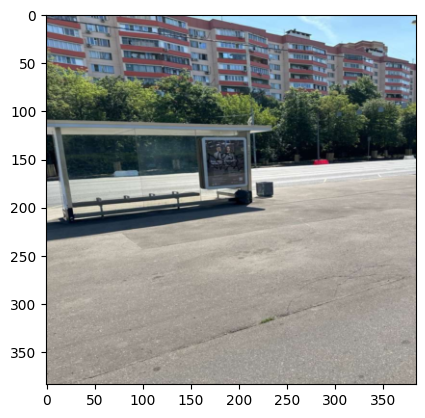

1.0
4431
{'probability': 0.9943287968635559, 'prediction': 1}


img                                 https://ckkb-mos.online/storage/uploads/images/10645/90605/4110781/0so0pUg4YpW3.jpg
attr                           Нарушения в содержание дорог, МАФов, остановочных павильонов, опор УНО, опор мосгортранс
attr_val                                                                                                            1.0
ID                                                                                                            177189658
img_num                                                                                                               0
Комментарий                                                                                                         NaN
Гостевая ссылка на проверку                               https://ckkb-mos.online/link/Bzv1G23wxoizwLPjf4MZjmqmq0FZdLzn
Name: 4431, dtype: object

In [ ]:
ind = 709
plt.imshow(facade[ind][0])
plt.show()
print(facade[ind][1])
print(facade.orig_indices[ind])
row = data.iloc[facade.orig_indices[ind]]
image_path = os.path.join(root_dir, img_dir, str(row["ID"]) + "_" + str(row["img_num"]) + ".jpg")

print(predict_image(model, image_path, default_transform, device, threshold=0.8))
row

In [ ]:
k = 0
d = train_ds
for ind in range(len(ds)):
    if ind not in d.indices:
        continue
    if data.iloc[ds.orig_indices[ind]].attr_val == 0:
        k += 1
        #print(ind)
        #plt.imshow(facade[ind][0])
        #plt.show()

print()
print(len(d))
print(k)
print(k / len(d))


6082
889
0.14616902334758303


In [ ]:
def predict_image(model, image_path, transform, device, threshold=0.5):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image = transform(image)

    image = image.unsqueeze(0)
    image = image.to(device)

    with torch.no_grad():
        logits = model(image)
        prob = torch.sigmoid(logits).item()
        pred = int(prob > threshold)

    return {
        "probability": prob,
        "prediction": pred
    }

In [ ]:
d = test_ds
imgs = []
for ind in range(len(ds)):
    if ind not in d.indices:
        continue
    if data.iloc[ds.orig_indices[ind]].attr_val == 0:
        imgs.append((data.iloc[ds.orig_indices[ind]].ID, data.iloc[ds.orig_indices[ind]].img_num))

In [ ]:
preds = np.zeros(len(imgs))
for ind, i in enumerate(imgs):
    preds[ind] = predict_image(model, os.path.join(root_dir, img_dir, str(i[0]) + "_" + str(i[1]) + ".jpg"), default_transform, device, threshold=0.9)["probability"]
preds.mean()

0.3566743034699287

### Загрузка

In [ ]:
device = "cuda"

In [ ]:
model = models.convnext_small()
model.classifier[2] = nn.Linear(model.classifier[2].in_features, 1, bias=True)
model.load_state_dict(torch.load("models/dedicated_classifiers/roads_bus_stops/convnext_s.pth", weights_only=True))
model.to(device);

#### Сохранение

In [ ]:
torch.save(model.state_dict(), "models/dedicated_classifiers/roads_bus_stops/convnext_s_2.pth")

In [ ]:
with open("fixed_test_sets/resident_facade.txt", "x") as f:
    for i in test_ds.indices:
        f.write(str(i) + "\n")

### Папки:
not_resident_facade

resident_facade

roads_bus_stops

sanitation_lighting

codd

## Классы

! дисбаланс по меткам указан как 0/1

---

### Нарушения в содержание дорог, МАФов, остановочных павильонов, опор УНО, опор мосгортранс
3763 объектов, дисбаланс 0.28/0.72

thresh = 0.7

accuracy: 0.8613

balanced accuracy: 0.8413

auc: 0.8969

---

### Нарушение содержания фасадов нежилых зданий и сооружений:
6990 объектов, дисбаланс 0.17/0.83

thresh = 0.8

accuracy: 0.8195

balanced accuracy: 0.7729

auc: 0.8699

---

### Нарушение содержания объектов гор.мост
1527 объектов, дисбаланс 0.64/0.36


---
### Нарушения по санитарии, освещению, ТПУ, полосе отвода ж\д:
3132 объектов, дисбаланс 0.33/0.67

thresh = 0.9

accuracy: acc = 0.83

balanced accuracy: 0.83

auc: 0.8699

---
### Нарушение содержания строительной площадки
641 объектов, дисбаланс 0.10/0.90


---
### Нарушение содержания мест проведения работ по комплексному благоустройству
859 объектов, дисбаланс 0.04/0.96


---
### Нарушение содержания мест проведения работ по ремонту инженерных сооружений
1382 объектов, дисбаланс 0.76/0.24


----
### Наличие подтоплений
1166 объектов, дисбаланс 0.83/0.17


---
### Нарушение содержания объектов ЦОДД

1707 объектов, дисбаланс 0.43/0.57

thresh = 0.65

accuracy: 0.7721

balanced accuracy: 0.7713

auc: 0.8574

---
### Нарушение содержания рекламных конструкций
1073 объектов, дисбаланс 0.91/0.09


---
### Нарушение состояния фасада жилых зданий
2068 объектов, дисбаланс 0.46/0.54

thresh = 0.4

accuracy: 0.9030

balanced accuracy: 0.8864

auc: 0.9522


---
### Наличие сухостойных деревьев (только деревья)
262 объектов, дисбаланс 0.00/1.00 (мда)


---
### Неудовлетворительное содержание ОЛХ
177 объектов (отлично), дисбаланс 0.07/0.93

In [ ]:
for i in data.attr.unique():
    count = len(data[data["attr"] == i])
    mean = data[data["attr"] == i]["attr_val"].mean()
    print(f"{i}:    {count}    {mean:.2f}")

Нарушения в содержание дорог, МАФов, остановочных павильонов, опор УНО, опор мосгортранс:    3763    0.72
Нарушение содержания фасадов нежилых зданий и сооружений:    6990    0.83
Нарушение содержания объектов гор.моста:    1527    0.36
Нарушения по санитарии, освещению, ТПУ, полосе отвода ж\д:    3132    0.67
Нарушение содержания строительной площадки:    641    0.90
Нарушение содержания мест проведения работ по комплексному благоустройству:    859    0.96
Нарушение содержания мест проведения работ по ремонту инженерных сооружений:    1382    0.24
Наличие подтоплений:    1166    0.17
Нарушение содержания объектов ЦОДД:    1707    0.43
Нарушение содержания рекламных конструкций:    1073    0.09
Нарушение состояния фасада жилых зданий:    2068    0.54
Наличие сухостойных деревьев (только деревья):    262    1.00
Неудовлетворительное содержание ОЛХ:    177    0.93
